# SmartStock ML Phase 7A — Baseline Forecast Evaluation

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/sebass369/smartstock-ml/blob/main/notebooks/phase_7_forecasting.ipynb)

## 1. Project and Privacy

This notebook evaluates transparent 14-day demand forecasts using only deterministic synthetic data and the nine approved public product aliases. Results are not sales records, operational guidance, ordering guidance, or evidence of real-world performance.

## 2. Reproducible Colab Setup

A fresh Colab runtime clones the approved Phase 7A branch and installs the project with its existing analysis dependencies. Local uploads, Google Drive, external datasets, and credentials are not required.

In [3]:
from pathlib import Path
import subprocess
import sys

REPOSITORY_URL = "https://github.com/sebass369/smartstock-ml.git"
SOURCE_REF = "main"

try:
    import google.colab  # type: ignore[import-not-found]  # noqa: F401
except ImportError:
    IN_COLAB = False
else:
    IN_COLAB = True

if IN_COLAB:
    project_root = Path("/content/smartstock-ml")
    if project_root.exists():
        raise RuntimeError(
            "Expected a fresh Colab runtime; restart and run all cells."
        )
    subprocess.run(
        [
            "git",
            "clone",
            "--quiet",
            "--branch",
            SOURCE_REF,
            "--single-branch",
            REPOSITORY_URL,
            str(project_root),
        ],
        check=True,
    )
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "--quiet", f"{project_root}[analysis]"],
        check=True,
    )
else:
    project_root = Path.cwd()
    if not (project_root / "PROJECT.md").is_file():
        raise RuntimeError(
            "Run this notebook from the SmartStock ML repository root."
        )

print(f"Project root: {project_root}")
print(f"Source ref: {SOURCE_REF}")

Project root: /content/smartstock-ml
Source ref: main


## 3. Generate Deterministic Forecasts

The notebook calls reusable package functions. It does not duplicate demand generation, forecast formulas, validation, or metric calculations.

In [4]:
import matplotlib.pyplot as plt
import pandas as pd

from smartstock.config import (
    load_delivery_config,
    load_generation_config,
    load_products_config,
)
from smartstock.forecasting import (
    generate_cycle_forecast_records,
    summarize_forecasts,
)
from smartstock.generator import generate_daily_records

DEFAULT_SEED = 42
CONFIG_ROOT = project_root / "config"
products_config = load_products_config(CONFIG_ROOT / "products.yaml")
delivery_config = load_delivery_config(CONFIG_ROOT / "delivery.yaml")
generation_config = load_generation_config(CONFIG_ROOT / "generation.yaml")
product_order = [product["product_id"] for product in products_config["products"]]

demand_records = generate_daily_records(
    products_config,
    delivery_config,
    generation_config,
    seed=DEFAULT_SEED,
)
forecast_records = generate_cycle_forecast_records(
    demand_records,
    products_config,
    delivery_config,
)
forecast_summary = summarize_forecasts(forecast_records, products_config)

## 4. Validate the Evaluation Contract

One 14-day warm-up cycle leaves three complete forecast origins. Each origin contains all nine products, for 27 records in stable origin and product order.

In [5]:
forecast_frame = pd.DataFrame(forecast_records)
for column in (
    "forecast_origin_date",
    "training_start_date",
    "training_end_date",
    "target_start_date",
    "target_end_date",
):
    forecast_frame[column] = pd.to_datetime(forecast_frame[column])
forecast_frame["product_id"] = pd.Categorical(
    forecast_frame["product_id"],
    categories=product_order,
    ordered=True,
)

assert len(forecast_frame) == 27
assert forecast_frame["product_id"].nunique() == 9
assert forecast_frame["forecast_origin_date"].nunique() == 3
forecast_frame.head(9)

,forecast_origin_date,training_start_date,training_end_date,target_start_date,target_end_date,product_id,actual_demand_units,baseline_prediction_units,candidate_prediction_units,baseline_absolute_error_units,candidate_absolute_error_units
0,2025-01-21,2025-01-07,2025-01-20,2025-01-21,2025-02-03,Milk_Product_A,57,58,58.0,1,1.0
1,2025-01-21,2025-01-07,2025-01-20,2025-01-21,2025-02-03,Milk_Product_B,70,72,72.0,2,2.0
2,2025-01-21,2025-01-07,2025-01-20,2025-01-21,2025-02-03,Whole_Milk,61,59,59.0,2,2.0
3,2025-01-21,2025-01-07,2025-01-20,2025-01-21,2025-02-03,Fruit_Refresher_A,64,65,65.0,1,1.0
4,2025-01-21,2025-01-07,2025-01-20,2025-01-21,2025-02-03,Fruit_Refresher_B,68,63,63.0,5,5.0
5,2025-01-21,2025-01-07,2025-01-20,2025-01-21,2025-02-03,Cold_Foam_A,63,67,67.0,4,4.0
6,2025-01-21,2025-01-07,2025-01-20,2025-01-21,2025-02-03,Whipped_Topping,61,57,57.0,4,4.0
7,2025-01-21,2025-01-07,2025-01-20,2025-01-21,2025-02-03,Skim_Milk,11,15,15.0,4,4.0
8,2025-01-21,2025-01-07,2025-01-20,2025-01-21,2025-02-03,Oat_Beverage,16,14,14.0,2,2.0


## 5. Baseline and Candidate

Phase 7A compares the previous completed cycle baseline with the expanding weekday-mean candidate. The baseline copies total demand from the previous completed 14-day cycle. The candidate estimates each future date from the product's expanding historical mean for the same weekday, then sums the 14 estimates. Both methods use only dates before the forecast origin, and neither method is a trained machine-learning model.

In [6]:
overall_metrics = pd.DataFrame(
    [
        {
            "method": "Previous completed cycle baseline",
            "mae_units": forecast_summary["overall"]["baseline_mae_units"],
            "wape_percent": forecast_summary["overall"]["baseline_wape_percent"],
        },
        {
            "method": "Expanding weekday mean candidate",
            "mae_units": forecast_summary["overall"]["candidate_mae_units"],
            "wape_percent": forecast_summary["overall"]["candidate_wape_percent"],
        },
    ]
)
overall_metrics.round(3)

,method,mae_units,wape_percent
0,Previous completed cycle baseline,3.407,6.376
1,Expanding weekday mean candidate,3.463,6.480


## 6. Actual Versus Predicted Demand

Small multiples keep all nine products readable. Each panel contains only three synthetic evaluation cycles, so visual differences must be interpreted cautiously.

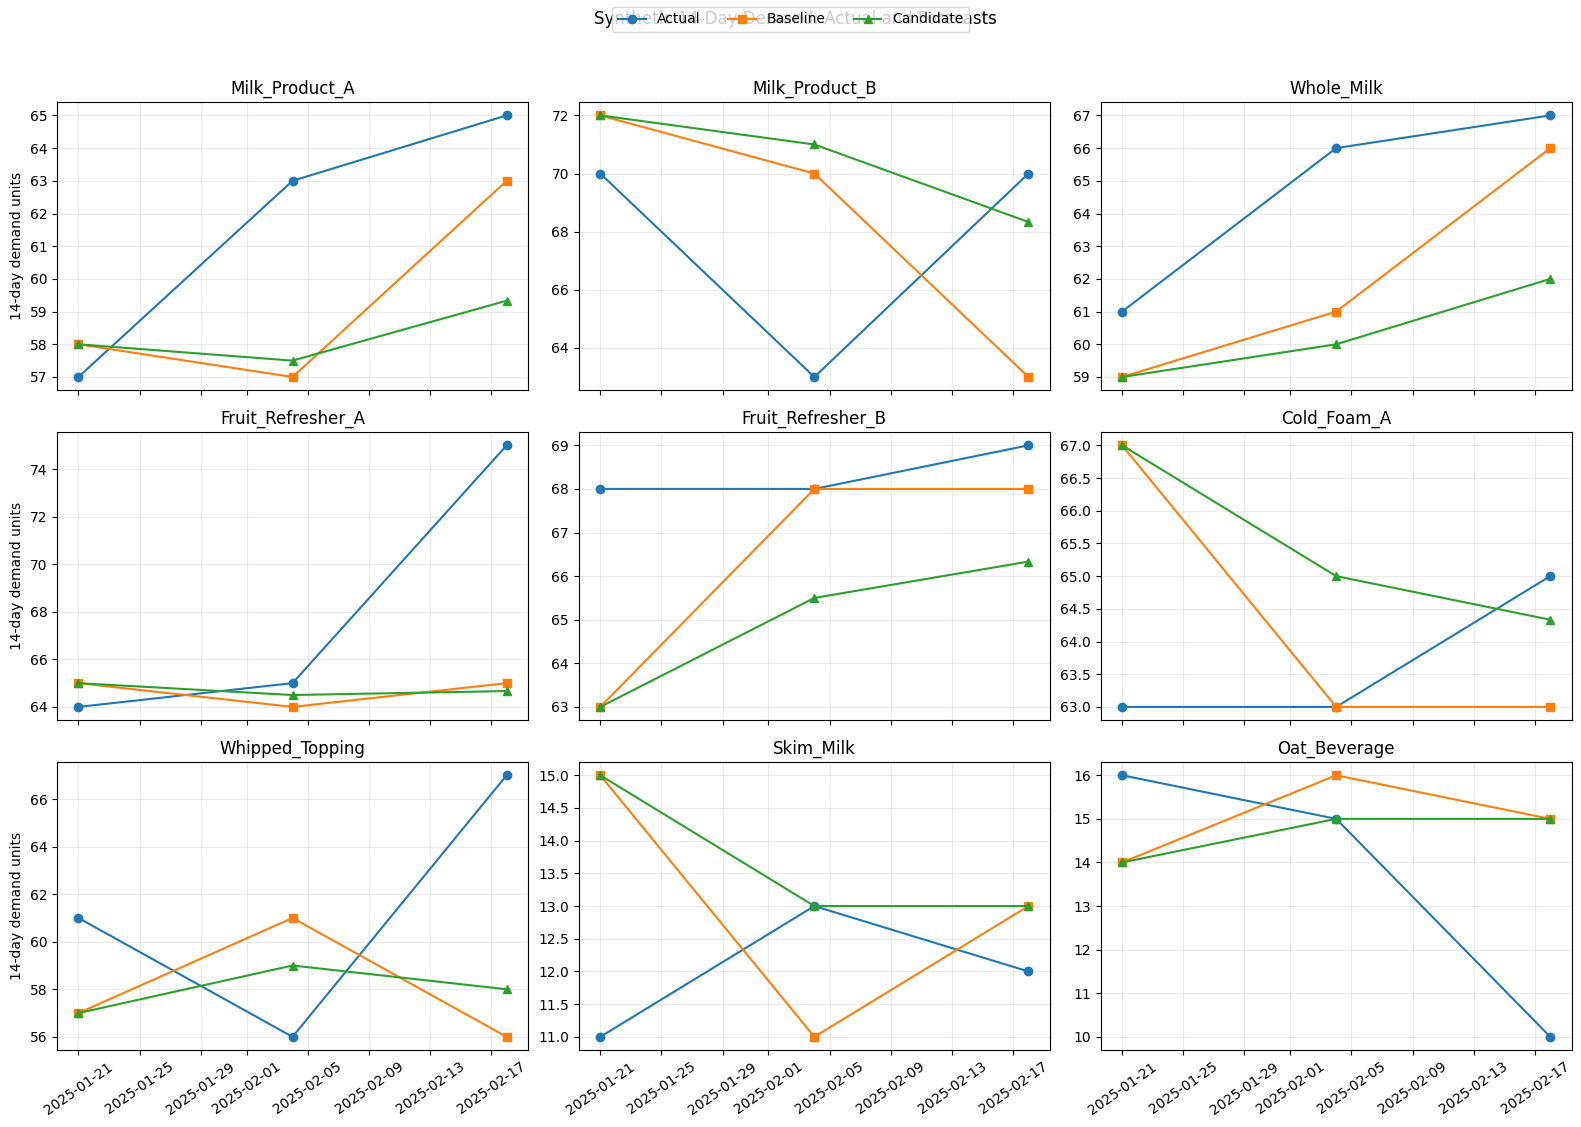

In [7]:
fig, axes = plt.subplots(3, 3, figsize=(16, 11), sharex=True)
for axis, product_id in zip(axes.flat, product_order, strict=True):
    product_frame = forecast_frame.loc[
        forecast_frame["product_id"] == product_id
    ]
    axis.plot(
        product_frame["forecast_origin_date"],
        product_frame["actual_demand_units"],
        marker="o",
        label="Actual",
    )
    axis.plot(
        product_frame["forecast_origin_date"],
        product_frame["baseline_prediction_units"],
        marker="s",
        label="Baseline",
    )
    axis.plot(
        product_frame["forecast_origin_date"],
        product_frame["candidate_prediction_units"],
        marker="^",
        label="Candidate",
    )
    axis.set_title(product_id)
    axis.grid(alpha=0.25)
    axis.tick_params(axis="x", rotation=35)
for axis in axes[:, 0]:
    axis.set_ylabel("14-day demand units")
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=3)
fig.suptitle("Synthetic 14-Day Demand: Actual and Forecasts", y=1.02)
fig.tight_layout()
plt.show()

## 7. Per-Product Error Comparison

MAE remains in demand units. Product-level candidate results use the approved absolute tie tolerance of `1e-9`.

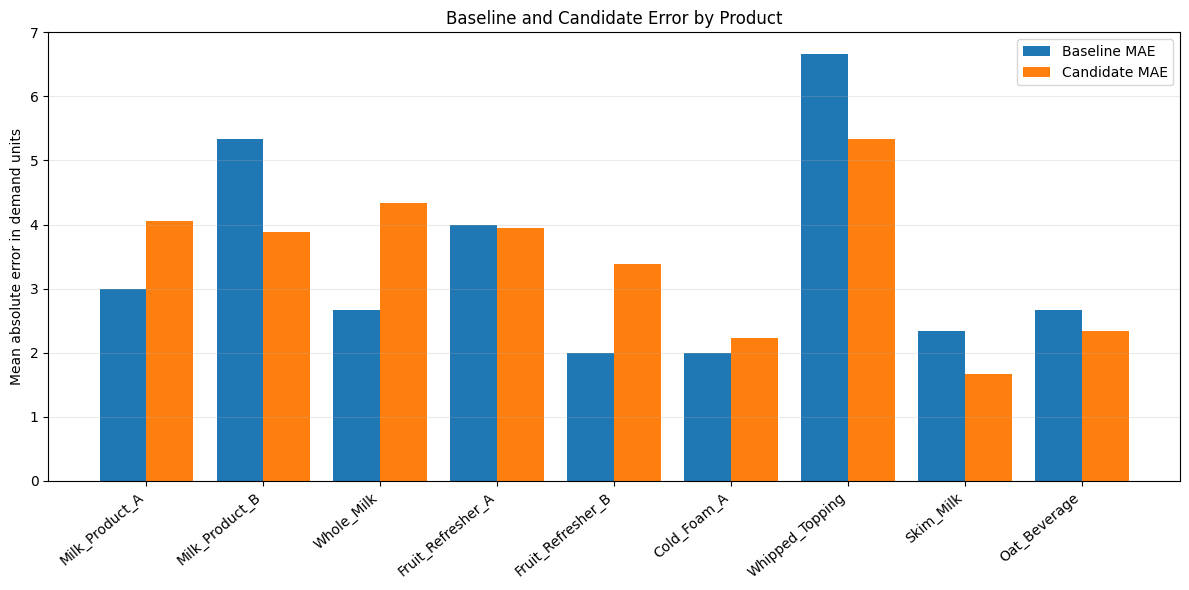

,product_id,forecast_count,baseline_mae_units,candidate_mae_units,baseline_wape_percent,candidate_wape_percent,candidate_result
0,Milk_Product_A,3,3.000,4.056,4.865,6.577,loss
1,Milk_Product_B,3,5.333,3.889,7.882,5.747,win
2,Whole_Milk,3,2.667,4.333,4.124,6.701,loss
3,Fruit_Refresher_A,3,4.000,3.944,5.882,5.801,win
4,Fruit_Refresher_B,3,2.000,3.389,2.927,4.959,loss
5,Cold_Foam_A,3,2.000,2.222,3.141,3.490,loss
6,Whipped_Topping,3,6.667,5.333,10.870,8.696,win
7,Skim_Milk,3,2.333,1.667,19.444,13.889,win
8,Oat_Beverage,3,2.667,2.333,19.512,17.073,win


In [8]:
product_metrics = pd.DataFrame(
    [
        {"product_id": product_id, **forecast_summary["by_product"][product_id]}
        for product_id in product_order
    ]
)
positions = range(len(product_order))
fig, axis = plt.subplots(figsize=(12, 6))
axis.bar(
    [position - 0.2 for position in positions],
    product_metrics["baseline_mae_units"],
    width=0.4,
    label="Baseline MAE",
)
axis.bar(
    [position + 0.2 for position in positions],
    product_metrics["candidate_mae_units"],
    width=0.4,
    label="Candidate MAE",
)
axis.set_xticks(list(positions), product_order, rotation=40, ha="right")
axis.set_ylabel("Mean absolute error in demand units")
axis.set_title("Baseline and Candidate Error by Product")
axis.legend()
axis.grid(axis="y", alpha=0.25)
fig.tight_layout()
plt.show()
product_metrics.round(3)

In [9]:
pd.DataFrame(
    [forecast_summary["candidate_product_result_counts"]]
).rename_axis("candidate comparison")

,wins,ties,losses
candidate comparison,,,
0,5,0,4


## 8. Limitations

- The dataset contains only 56 deterministic synthetic days and three evaluation cycles.
- The first candidate cycle total ties the baseline by construction because the warm-up contains two observations for every weekday.
- The generator contains configured weekday effects and seeded random variation; results do not represent customer behavior.
- WAPE is calculated as `100.0 * sum(abs(actual - prediction)) / sum(actual)`, may exceed 100.0, and is unavailable when total actual demand is zero.
- No accuracy threshold or combined score is defined.
- Forecasts are not fed into ordering, inventory simulation, optimization, deployment, or a dashboard.
- Phase 7B — Simple Machine Learning Model is future work. This notebook does not implement Ridge regression, scikit-learn, or other machine-learning behavior.
- Candidate wins, ties, and losses describe this synthetic scenario only and do not establish real-world superiority.